In [2]:
import sys
import os
# get to project root
os.chdir('..')
print(os.getcwd())

C:\Users\monam\OneDrive\Desktop\UNI\II\PartIIProject\CST-Part-II-Project-Code


In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json

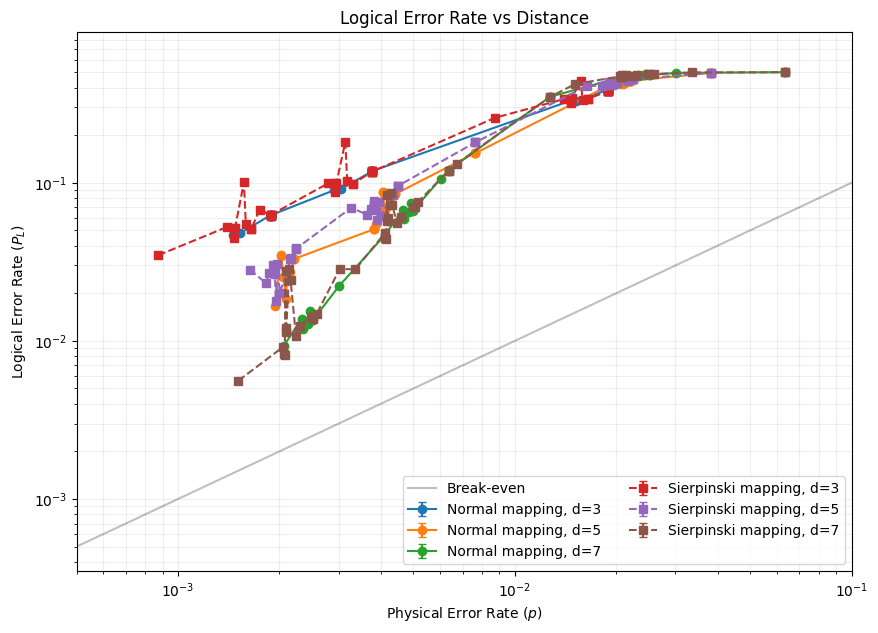

In [4]:
# want to plot difference between normal + sierpinski mapping - Logical error rate

cc_data_path = r".\data\cc_data_tri_part.json"
cc_tri_data_path = r".\data\color_code_first_run_data.json"

with open(cc_data_path, 'r') as f:
    raw_data = json.load(f)

with open(cc_tri_data_path,'r') as f:
    raw_tri_data = json.load(f)

records = []
records_tri = []

# Assuming 'Forwarding' is your algorithm name based on your print output
label = 'Forwarding' 

# We need to extract these dictionaries from the raw JSON
# Depending on how your JSON is saved, keys might be inverted. 
# Based on your print(df) output, it looks like: data[Metric][Algorithm][d][capacity]
# Let's try to grab the dictionaries directly.

# Adjust these keys if your JSON nesting order is slightly different
log_errs_dict = raw_data['LogicalErrorRates'][label]
log_errs_tri_dict = raw_tri_data['LogicalErrorRates'][label]
phys_x_dict = raw_data['PhysicalXErrorRates'][label]
phys_x_tri_dict = raw_tri_data['PhysicalXErrorRates'][label]
phys_z_dict = raw_data['PhysicalZErrorRates'][label]
phys_z_tri_dict = raw_tri_data['PhysicalZErrorRates'][label]

# Iterate through the nested structure
for d_str, cap_dict in log_errs_dict.items():
    d = int(d_str)
    for cap_str, log_err_list in cap_dict.items():
        capacity = int(cap_str)
        
        # Get corresponding physical error rates
        phys_x_list = phys_x_dict[d_str][cap_str]
        phys_z_list = phys_z_dict[d_str][cap_str]
        
        # Combine the lists into rows for our DataFrame
        for i, log_err in enumerate(log_err_list):
            px = phys_x_list[i]
            pz = phys_z_list[i]
            
            # Standard practice: define p as the average or max of X/Z errors
            p_physical = (px + pz) / 2
            
            records.append({
                'd': d,
                'capacity': capacity,
                'p': p_physical,
                'logical_error_rate': log_err,
                'shots': 1000000 
            })

for d_str, cap_dict in log_errs_tri_dict.items():
    d = int(d_str)
    for cap_str, log_err_list in cap_dict.items():
        capacity = int(cap_str)
        
        # Get corresponding physical error rates
        phys_x_list = phys_x_tri_dict[d_str][cap_str]
        phys_z_list = phys_z_tri_dict[d_str][cap_str]
        
        # Combine the lists into rows for our DataFrame
        for i, log_err in enumerate(log_err_list):
            px = phys_x_list[i]
            pz = phys_z_list[i]
            
            # Standard practice: define p as the average or max of X/Z errors
            p_physical = (px + pz) / 2
            
            records_tri.append({
                'd': d,
                'capacity': capacity,
                'p': p_physical,
                'logical_error_rate': log_err,
                'shots': 1000000 
            })
            
# Create the clean, flat DataFrame
df = pd.DataFrame(records)
df_tri = pd.DataFrame(records_tri)

plt.figure(figsize=(10, 7))

datasets = [
    (df, "Normal mapping", '-', 'o'),
    (df_tri, "Sierpinski mapping", '--', 's'),
]

for data, name, ls, marker in datasets:
    distances = sorted(data['d'].unique())

    for d in distances:
        subset = data[data['d'] == d].sort_values('p')

        subset['std_err'] = np.sqrt(
            subset['logical_error_rate']
            * (1 - subset['logical_error_rate'])
            / subset['shots']
        )

        plt.errorbar(
            subset['p'],
            subset['logical_error_rate'],
            yerr=subset['std_err'],
            label=f'{name}, d={d}',
            linestyle=ls,
            marker=marker,
            capsize=3
        )

# --- Styling ---
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Physical Error Rate ($p$)')
plt.ylabel('Logical Error Rate ($P_L$)')
plt.xlim(5e-4, 1e-1)
plt.title('Logical Error Rate vs Distance')
plt.grid(True, which="both", alpha=0.2)

# Break-even line
lims = [
    min(plt.xlim()[0], plt.ylim()[0]),
    max(plt.xlim()[1], plt.ylim()[1])
]
plt.plot(lims, lims, 'k-', alpha=0.25, label='Break-even')

plt.legend(ncol=2)
plt.show()


   d  capacity  op_num    shots experiment
0  3         6     560  1000000     Normal
1  3         7     560  1000000     Normal
2  3         8     560  1000000     Normal
3  3         5     663  1000000     Normal
4  3         9     560  1000000     Normal
   d  capacity  op_num    shots  experiment
0  3        12     317  1000000  Sierpinski
1  3        11     317  1000000  Sierpinski
2  3         8     546  1000000  Sierpinski
3  3        10     498  1000000  Sierpinski
4  3         9     498  1000000  Sierpinski


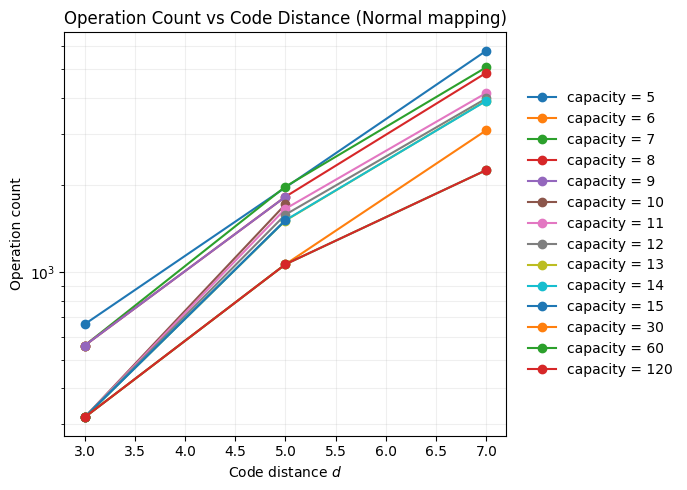

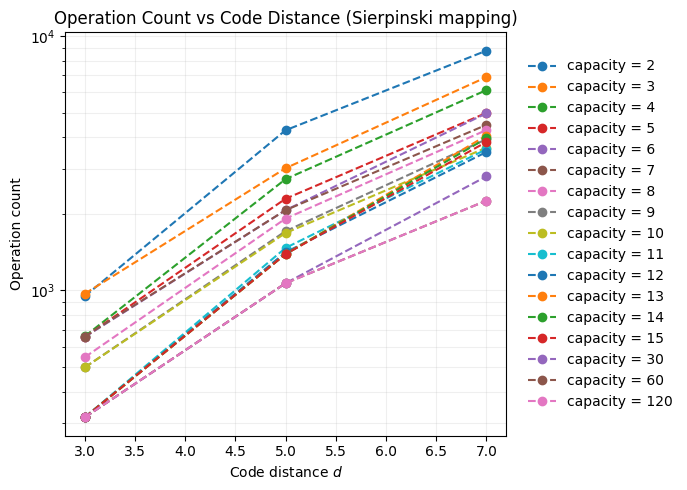

In [7]:
# want to plot difference between normal + sierpinski mapping - Operations

cc_data_path = r".\data\cc_data_tri_part.json"
cc_tri_data_path = r".\data\color_code_first_run_data.json"

with open(cc_data_path, 'r') as f:
    raw_data = json.load(f)

with open(cc_tri_data_path,'r') as f:
    raw_tri_data = json.load(f)

records = []
records_tri = []

# Assuming 'Forwarding' is your algorithm name based on your print output
label = 'Forwarding' 

# We need to extract these dictionaries from the raw JSON
# Depending on how your JSON is saved, keys might be inverted. 
# Based on your print(df) output, it looks like: data[Metric][Algorithm][d][capacity]
# Let's try to grab the dictionaries directly.

# Adjust these keys if your JSON nesting order is slightly different
ops_dict = raw_data['Operations'][label]
ops_tri_dict = raw_tri_data['Operations'][label]

# Iterate through the nested structure
for d_str, cap_dict in ops_dict.items():
    d = int(d_str)
    for cap_str, op_num in cap_dict.items():
        capacity = int(cap_str)
        records.append({
            'd': d,
            'capacity': capacity,
            'op_num': op_num,
            'shots': 1000000 
        })

for d_str, cap_dict in ops_tri_dict.items():
    d = int(d_str)
    for cap_str, op_num in cap_dict.items():
        capacity = int(cap_str)
        records_tri.append({
            'd': d,
            'capacity': capacity,
            'op_num': op_num,
            'shots': 1000000 
        })

# Create the clean, flat DataFrame
df = pd.DataFrame(records)
df_tri = pd.DataFrame(records_tri)
df['experiment'] = 'Normal'
df_tri['experiment'] = 'Sierpinski'
df_all = pd.concat([df, df_tri], ignore_index=True)

print(df.head())
print(df_tri.head())

linestyles = {'Normal':'-', 'Sierpinski':'--'}

for experiment in ['Normal', 'Sierpinski']:
    plt.figure(figsize=(7, 5))
    data = df_all[df_all['experiment'] == experiment]

    for i, capacity in enumerate(sorted(data['capacity'].unique())):
        subset = data[data['capacity'] == capacity].sort_values('d')

        plt.plot(
            subset['d'],
            subset['op_num'],
            linestyle=linestyles[experiment],
            marker='o',
            label=f'capacity = {capacity}'
        )

    plt.xlabel('Code distance $d$')
    plt.ylabel('Operation count')
    plt.yscale('log')
    plt.title(f'Operation Count vs Code Distance ({experiment} mapping)')
    plt.grid(True, which='both', alpha=0.2)
    plt.legend(
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        frameon=False
    )
    plt.tight_layout()
    plt.show()



Common capacities: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 30, 60, 120]
    d  capacity  op_num    shots  experiment
3   3         5     663  1000000      Normal
28  7         5    5802  1000000      Normal
41  3         5     656  1000000  Sierpinski
58  5         5    2292  1000000  Sierpinski
65  7         5    4983  1000000  Sierpinski


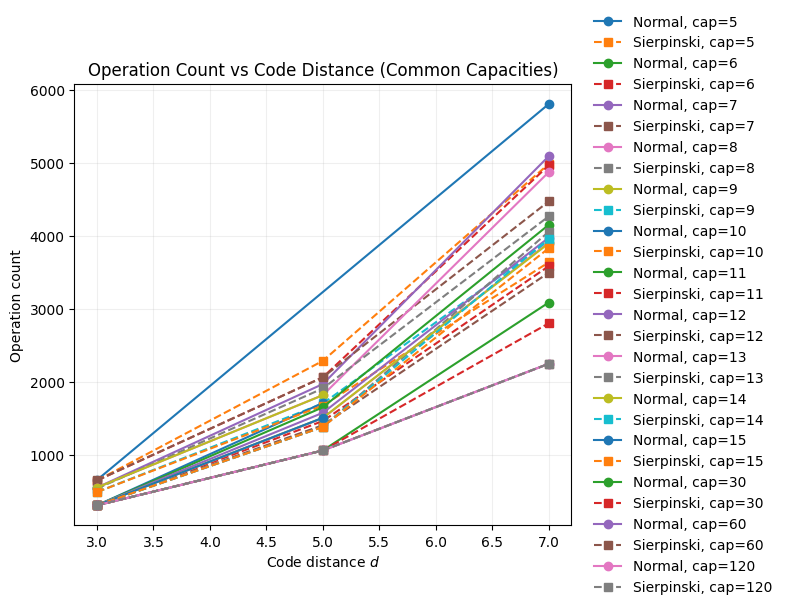

In [8]:
# want to plot difference between normal + sierpinski mapping - Operations - plot only common capacities

cc_data_path = r".\data\cc_data_tri_part.json"
cc_tri_data_path = r".\data\color_code_first_run_data.json"

with open(cc_data_path, 'r') as f:
    raw_data = json.load(f)

with open(cc_tri_data_path,'r') as f:
    raw_tri_data = json.load(f)

records = []
records_tri = []

# Assuming 'Forwarding' is your algorithm name based on your print output
label = 'Forwarding' 

# We need to extract these dictionaries from the raw JSON
# Depending on how your JSON is saved, keys might be inverted. 
# Based on your print(df) output, it looks like: data[Metric][Algorithm][d][capacity]
# Let's try to grab the dictionaries directly.

# Adjust these keys if your JSON nesting order is slightly different
ops_dict = raw_data['Operations'][label]
ops_tri_dict = raw_tri_data['Operations'][label]

# Iterate through the nested structure
for d_str, cap_dict in ops_dict.items():
    d = int(d_str)
    for cap_str, op_num in cap_dict.items():
        capacity = int(cap_str)
        records.append({
            'd': d,
            'capacity': capacity,
            'op_num': op_num,
            'shots': 1000000 
        })

for d_str, cap_dict in ops_tri_dict.items():
    d = int(d_str)
    for cap_str, op_num in cap_dict.items():
        capacity = int(cap_str)
        records_tri.append({
            'd': d,
            'capacity': capacity,
            'op_num': op_num,
            'shots': 1000000 
        })

# Create the clean, flat DataFrame
df = pd.DataFrame(records)
df_tri = pd.DataFrame(records_tri)

common_caps = sorted(
    set(df['capacity']).intersection(df_tri['capacity'])
)

print("Common capacities:", common_caps)
df_common = df[df['capacity'].isin(common_caps)].copy()
df_tri_common = df_tri[df_tri['capacity'].isin(common_caps)].copy()

df_common['experiment'] = 'Normal'
df_tri_common['experiment'] = 'Sierpinski'
df_all = pd.concat([df_common, df_tri_common], ignore_index=True)

print(df_all[df_all['capacity']==5])
plt.figure(figsize=(8, 6))

linestyles = {'Normal': '-', 'Sierpinski': '--'}
markers = {'Normal': 'o', 'Sierpinski': 's'}

for (capacity, experiment), subset in df_all.groupby(['capacity', 'experiment']):
    subset = subset.sort_values('d')

    plt.plot(
        subset['d'],
        subset['op_num'],
        linestyle=linestyles[experiment],
        marker=markers[experiment],
        label=f'{experiment}, cap={capacity}'
    )

plt.xlabel('Code distance $d$')
plt.ylabel('Operation count')
#plt.yscale('log')
plt.title('Operation Count vs Code Distance (Common Capacities)')
plt.grid(True, which='both', alpha=0.2)
plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
plt.tight_layout()
plt.show()
